In [ ]:
# Tải file GloVe (bản 6B - 50 chiều)
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip
# Tạo thư mục datasets nếu chưa có
!mkdir -p datasets
!mv glove.6B.50d.txt datasets/

--2025-12-18 10:23:11--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-12-18 10:23:11--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-12-18 10:23:11--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

words = []
vectors = []

# Đọc vector từ file
with open('datasets/glove.6B.50d.txt', 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) > 50: # Đảm bảo dòng hợp lệ
            words.append(parts[0])
            vectors.append([float(x) for x in parts[1:]])

words = np.array(words)
vectors = np.array(vectors, dtype=np.float32)

print(f'Tổng số từ: {len(words)}')
print(f'Số chiều ban đầu: {vectors.shape[1]}')

Tổng số từ: 400000
Số chiều ban đầu: 50


In [ ]:
# Giảm chiều
pca = PCA(n_components=2)
vectors_reduced = pca.fit_transform(vectors)

print("Đã hoàn thành giảm chiều dữ liệu.")

Đã hoàn thành giảm chiều dữ liệu.


In [ ]:
def plot_words(target_words):
    plt.figure(figsize=(12, 8))

    # Vẽ nền các từ khác (màu xám nhạt để thấy mật độ dữ liệu)
    plt.scatter(vectors_reduced[:10000, 0], vectors_reduced[:10000, 1], s=1, alpha=0.05, color='gray')

    for word in target_words:
        idx = np.where(words == word)[0]
        if len(idx) == 0:
            print(f"[!] Không tìm thấy từ '{word}'")
            continue

        x, y = vectors_reduced[idx[0]]
        plt.scatter(x, y, color='red', s=60, zorder=5)
        plt.text(x + 0.05, y + 0.05, word, fontsize=12, fontweight='bold', color='darkred')

    plt.title(f"Phân tích nhóm từ: {', '.join(target_words)}")
    plt.grid(alpha=0.3)
    plt.show()

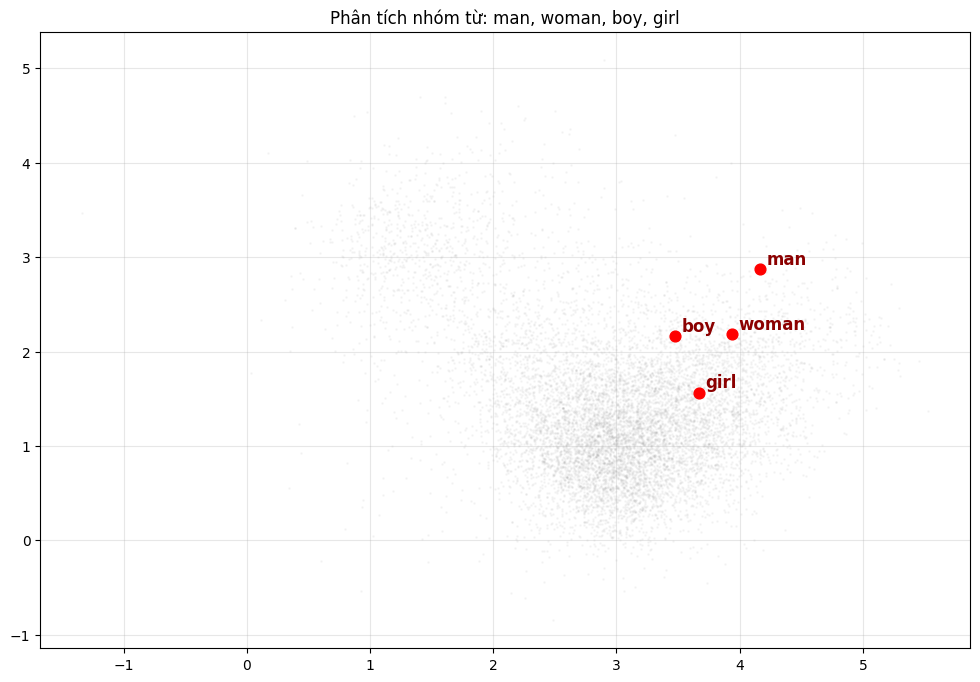

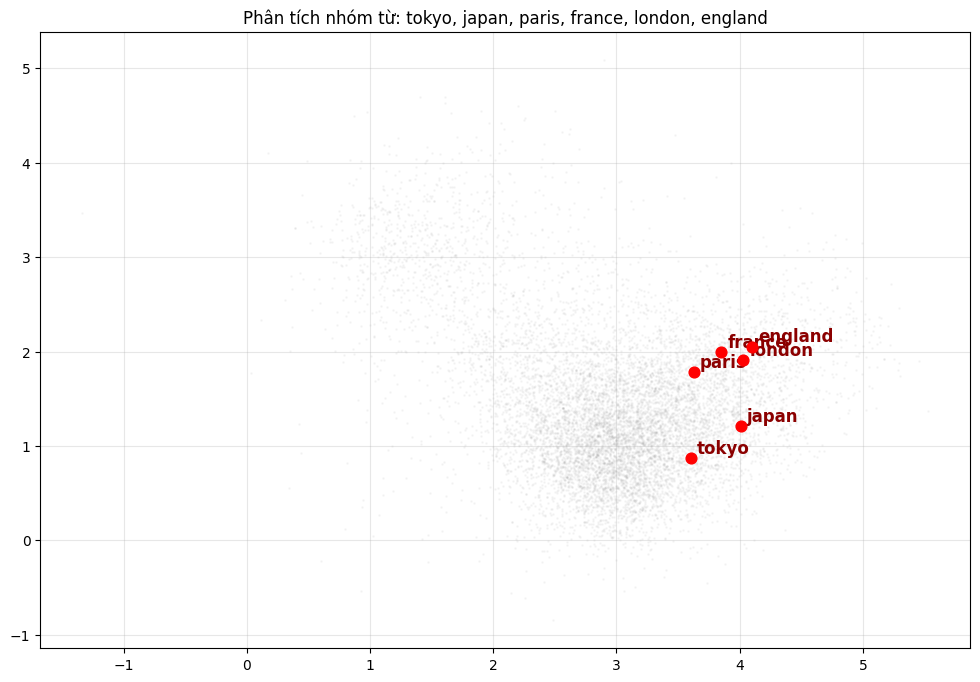

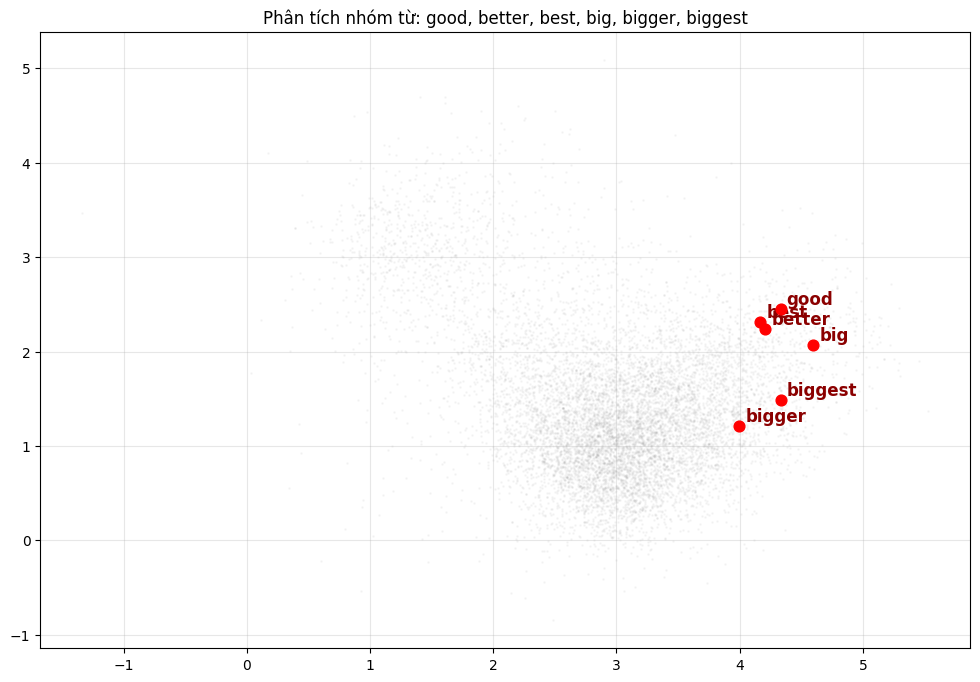

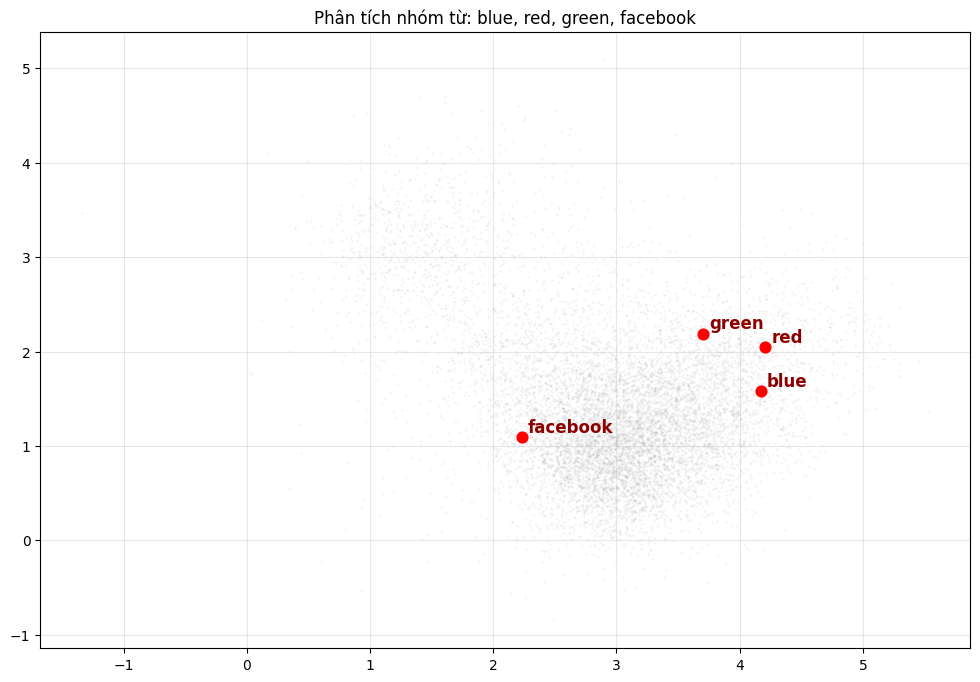

In [ ]:
# Kịch bản 1: Giới tính
plot_words(['man', 'woman', 'boy', 'girl'])

# Kịch bản 2: Thủ đô và Quốc gia (Tính chất bắc cầu)
plot_words(['tokyo', 'japan', 'paris', 'france', 'london', 'england'])

# Kịch bản 3: So sánh hơn và nhất
plot_words(['good', 'better', 'best', 'big', 'bigger', 'biggest'])

# Kịch bản 4: Sự khác biệt ngữ cảnh (Outlier)
plot_words(['blue', 'red', 'green', 'facebook'])

Nhận xét chung:
- Các từ cùng nhóm (màu sắc, giới tính, quốc gia) tự động nằm gần nhau. Điều này chứng minh vector đã học được ngữ nghĩa thay vì chỉ là ký tự thuần túy.

- Các cặp từ có mối quan hệ tương ứng (Thành phố - Quốc gia) tạo thành các đoạn thẳng gần như song song. Điều này cho thấy mô hình nắm bắt được logic/tri thức thế giới.

- Từ không liên quan (facebook) bị đẩy ra xa khỏi nhóm từ mục tiêu (màu sắc), cho thấy khả năng phân loại ngữ cảnh tốt.
- Do giảm chiều quá sâu (50 xuống 2), một số quan hệ bị chồng lấn. Tuy nhiên, các từ phổ biến vẫn giữ được vị trí chính xác nhờ dữ liệu huấn luyện dồi dào.